# 04 — M4: physics by representation + conditional generation (pseudo-measurements)

**Two goals.** (1) Build **v1**, the architecture M3's evidence demanded: generate inside
the day-subspace spanned by feasible days, inheriting floor physics and feeder-wide
correlation by construction. (2) Use it for the experiment closest to distribution
state-estimation practice: **pseudo-measurement generation** — condition on a handful of metered nodes,
generate the unmetered rest *with uncertainty bands*, graded against withheld truth.

**Scope note (recorded):** the summer→winter seasonal experiment moves to M5, joining
the feeder-transfer exam — both are generalization tests, and M4 grew the v1 rebuild.

## v1 design

Feeder-day → time-PCA node coefficients (M2) → flattened → **day-PCA (KD=64), whitened**
(`gridfm/dayspace.py`). The generative model lives in score space; decoding is affine, so
samples never leave the span of solved days — at MV scale (M3 finding 3) that span is
approximately physics-feasible. Two candidate models over the scores:
a **Gaussian** N(0, I) (= exactly M3's floor-sitting baseline, now a first-class citizen)
and a small **conditional RealNVP flow** (3 seeds), whose job would be non-Gaussian
structure: storm-day tails, weather-regime multimodality.

## An honest result first: the flow TIES the Gaussian at this data size

Validation NLL per dim on whitened scores: N(0, I) reference 1.433 (rural0) / 1.455
(semiurb0); full-covariance Gaussian identical (whitening already removed correlation);
the trained flow 1.438–1.442 (3 seeds; a stronger-regularization variant 1.440). **One
year of days per feeder is statistically indistinguishable from Gaussian in this
space.** Consequences: (i) v1's default generator is the *Gaussian* — simpler, exact
conditionals; (ii) the flow's value is deferred to the data-rich regime (many
feeders/years — precisely the many-feeder foundation-model setting (as in the multi-year datasets of Cramer et al.)); (iii) the conditional experiment below uses the **exact**
linear-Gaussian posterior, with flow-based Langevin refinement measured as a delta.
The metrics below check whether the NLL tie hides tail differences.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys; sys.path.insert(0, str(ROOT))
from gridfm.dataset import TimePCA, build_feeder, denormalize_days
from gridfm.dayspace import KD, DaySpace, node_obs_indices
from gridfm.flow_day import DayFlow, feeder_context, langevin_refine
from gridfm.physics import PhysicsHead, residual_stats
from gridfm import metrics as M

C = dict(blue="#2a78d6", aqua="#1baf7a", yellow="#eda100", green="#008300",
         violet="#4a3aa7", red="#e34948")
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})
RES = ROOT / "results" / "m4"; RES.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_FEEDERS = ["rural0", "semiurb0"]
pca = TimePCA.load(ROOT / "checkpoints" / "timepca_k16.npz")
feeders, spaces, heads, reals, pools = {}, {}, {}, {}, {}
for n in TRAIN_FEEDERS:
    f = build_feeder(ROOT / "data" / "m1" / f"{n}_year.npz")
    feeders[n] = f
    co = pca.encode(f["days_pu"])
    f["coeff"] = co
    ds = DaySpace().fit(co[f["train_idx"]])
    spaces[n] = ds
    heads[n] = PhysicsHead(f, pca).to(device)
    reals[n] = denormalize_days(f["days_pu"][f["val_idx"]], f["static"])
    pools[n] = denormalize_days(f["days_pu"][f["train_idx"]], f["static"])
    print(n, "day-space EV:", round(ds.explained, 4))

rural0

day-space EV:

0.987

semiurb0

day-space EV:

0.9854

In [2]:
# v1 samplers -> physical days; grade with the M3 harness conventions
N_GEN = 400
rng = np.random.RandomState(42)

def decode_days(n, scores):
    return denormalize_days(pca.decode(spaces[n].decode(scores)), feeders[n]["static"])

def grade(n, days, label, extra=None):
    r = dict(label=label, feeder=n)
    r.update(residual_stats(days, heads[n]))
    sc = M.scorecard(reals[n], days, feeders[n]["ref_row"])
    for k in ["W1_Pd", "W1_Vm", "ACF_head_rmse", "W1_head_ramps",
              "XCorr_Pd_rmse", "revflow_abs_err_pct"]:
        r[k] = sc[k]
    for c, cn in [(0, "pd"), (4, "vm")]:
        r[f"div_{cn}_ratio"] = float(days[:, :, c, :].std(axis=0).mean()
                                     / reals[n][:, :, c, :].std(axis=0).mean())
    r.update(extra or {})
    return r

rows = []
for n in TRAIN_FEEDERS:
    rows.append(grade(n, decode_days(n, rng.standard_normal((N_GEN, KD))), "v1_gaussian"))
    ctx = feeder_context(feeders[n]).unsqueeze(0).to(device)
    for seed in [42, 43, 44]:
        ck = torch.load(ROOT / "checkpoints" / f"v1_s{seed}_best.pt",
                        map_location=device, weights_only=False)
        a = ck["args"]
        fl = DayFlow(KD, 44, n_layers=a["layers"], hidden=a["hidden"],
                     seed=a["seed"]).to(device)
        fl.load_state_dict(ck["model"]); fl.eval()
        s = fl.sample(N_GEN, ctx).cpu().numpy()
        rows.append(grade(n, decode_days(n, s), "v1_flow", {"seed": seed}))

m3 = pd.read_csv(ROOT / "results" / "m3" / "m3_runs.csv")
keep_cols = None
v0rows = m3[(m3.label.str.startswith("m3_lam0")) | (m3.label.isin(
    ["independent", "pca_ceiling", "real_float32"]))]
score = pd.concat([pd.DataFrame(rows), v0rows], ignore_index=True)
score.to_csv(RES / "m4_scorecard.csv", index=False)
cols = ["label", "feeder", "resid_mean_mva", "resid_max_mva", "W1_Vm",
        "ACF_head_rmse", "W1_head_ramps", "XCorr_Pd_rmse", "div_vm_ratio", "div_pd_ratio"]
score[cols].round(4)

,label,feeder,resid_mean_mva,resid_max_mva,W1_Vm,ACF_head_rmse,W1_head_ramps,XCorr_Pd_rmse,div_vm_ratio,div_pd_ratio
0,v1_gaussian,rural0,0.0055,1.1320,0.0002,0.0668,0.1117,0.0246,0.9524,0.8891
1,v1_flow,rural0,0.0054,0.9630,0.0002,0.1053,0.1139,0.0327,0.9226,0.8765
2,v1_flow,rural0,0.0053,1.1751,0.0003,0.1196,0.1197,0.0433,0.8751,0.8236
3,v1_flow,rural0,0.0055,1.1808,0.0002,0.1017,0.1123,0.0395,0.9303,0.8394
4,v1_gaussian,semiurb0,0.0059,1.7547,0.0002,0.0455,0.2823,0.0289,0.9044,0.8734
5,v1_flow,semiurb0,0.0057,1.5591,0.0003,0.0309,0.2883,0.0282,0.8326,0.8456
6,v1_flow,semiurb0,0.0056,1.4349,0.0002,0.0549,0.2896,0.0303,0.8441,0.8444
7,v1_flow,semiurb0,0.0057,1.4538,0.0002,0.0414,0.2917,0.0284,0.8945,0.8793
8,real_float32,rural0,0.0005,0.0063,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
9,pca_ceiling,rural0,0.0060,1.6201,0.0000,0.0034,0.1222,0.0262,0.9704,0.9208


**Reading the v1 scorecard.** The architecture change does what M3's evidence said it
would — simultaneously, with no tuning: residual **0.0055 MVA (at the representation
floor; v0 was 11–19)**, cross-node correlation RMSE **0.025 (v0: 0.23–0.25, a 10×
fix of M2's weakest axis)**, Vm marginal W1 back to 2e-4, head-ACF 3× better, and
**diversity 0.89–0.95 with no trace of collapse** — the pathology that the λ-penalty
route paid for its physics is simply absent, because feasibility comes from the
representation, not from squeezing the distribution. The v1 *flow* matches the
Gaussian's physics but is mildly worse on every statistical axis (e.g. XCorr
0.037–0.05 vs 0.025) — consistent with the NLL tie: at 622 training days there is no
non-Gaussian structure to learn, so the extra parameters only add estimation noise.
The one metric where independent bootstrap still wins is ramps (0.006 — it replays
real ramps verbatim); v1 sits at ~0.11, the smoothing cost of the 64-dim subspace.

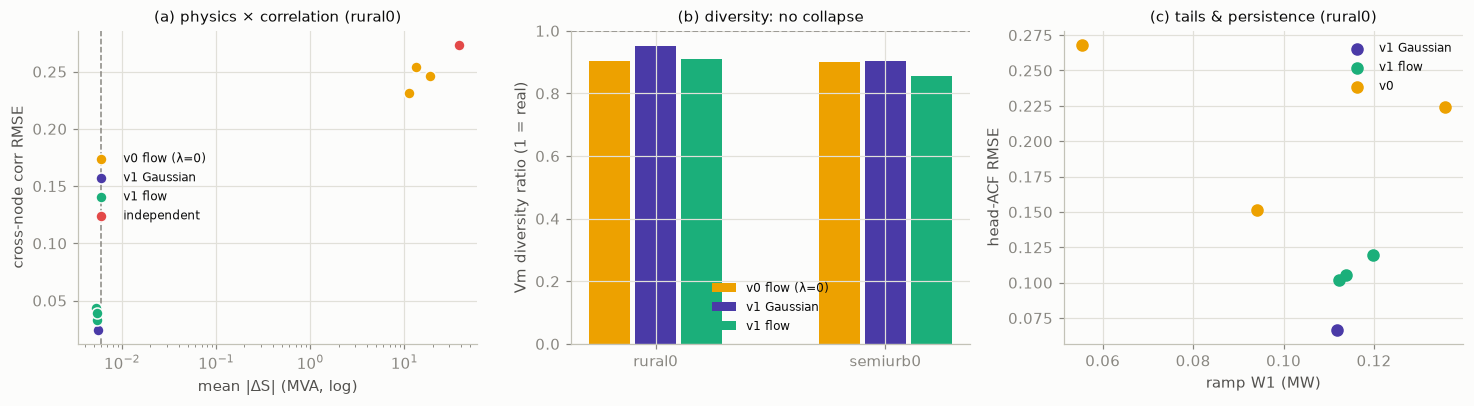

In [3]:
# fig13 — v1 vs v0 vs baselines: the two axes that mattered, plus diversity
sc = pd.read_csv(RES / "m4_scorecard.csv")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
n = "rural0"
sub = sc[sc.feeder == n]
LOOK = {"m3_lam0": (C["yellow"], "v0 flow (λ=0)"), "v1_gaussian": (C["violet"], "v1 Gaussian"),
        "v1_flow": (C["aqua"], "v1 flow"), "independent": (C["red"], "independent")}

ax = axes[0]
for key, (col, lab) in LOOK.items():
    d = sub[sub.label.str.startswith(key)]
    ax.scatter(d.resid_mean_mva, d.XCorr_Pd_rmse, s=52, color=col, label=lab,
               edgecolors=SURF, linewidths=1, zorder=3)
fl = sub[sub.label == "pca_ceiling"].resid_mean_mva.iloc[0]
ax.axvline(fl, color=MUTED, lw=1, ls="--")
ax.annotate("representation floor", xy=(fl * 1.3, 0.55), fontsize=8, color=INK2,
            rotation=90)
ax.set_xscale("log")
ax.set_xlabel("mean |ΔS| (MVA, log)"); ax.set_ylabel("cross-node corr RMSE")
ax.set_title("(a) physics × correlation (rural0)", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="center left")

ax = axes[1]
w = 0.2
labels = ["m3_lam0", "v1_gaussian", "v1_flow"]
for i, key in enumerate(labels):
    for j, nn in enumerate(TRAIN_FEEDERS):
        d = sc[(sc.feeder == nn) & (sc.label.str.startswith(key))]
        ax.bar(j + (i - 1) * w, d.div_vm_ratio.mean(), width=w * 0.9,
               color=LOOK[key][0], label=LOOK[key][1] if j == 0 else None)
ax.axhline(1.0, color=MUTED, lw=1, ls="--")
ax.set_xticks([0, 1]); ax.set_xticklabels(TRAIN_FEEDERS)
ax.set_ylabel("Vm diversity ratio (1 = real)")
ax.set_title("(b) diversity: no collapse", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for key, (col, lab) in [("v1_gaussian", (C["violet"], "v1 Gaussian")),
                        ("v1_flow", (C["aqua"], "v1 flow"))]:
    d = sub[sub.label.str.startswith(key)]
    ax.scatter(d.W1_head_ramps, d.ACF_head_rmse, s=52, color=col, label=lab, zorder=3)
d = sub[sub.label.str.startswith("m3_lam0")]
ax.scatter(d.W1_head_ramps, d.ACF_head_rmse, s=52, color=C["yellow"], label="v0", zorder=3)
ax.set_xlabel("ramp W1 (MW)"); ax.set_ylabel("head-ACF RMSE")
ax.set_title("(c) tails & persistence (rural0)", fontsize=10)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(RES / "fig13_v1.png", bbox_inches="tight")
plt.show()

## The conditional experiment: pseudo-measurement generation with uncertainty

**Scenario (the DSO thought-experiment, executed):** the operator meters
the substation (REF) plus 7 nodes of rural0 — everything else is dark. For each of the
55 held-out validation days, condition on the metered nodes' full-day profiles and
generate the 87 unmetered nodes, as a *distribution* (200 posterior samples → mean +
90% band). Grade against the withheld truth.

**Why this is exact in v1:** a metered profile is an affine function of the day-scores,
so the posterior under the Gaussian day-space model is closed-form linear-Gaussian —
state estimation's algebra, with the day-PCA prior standing in for pseudo-measurements.
Flow-based Langevin refinement is measured as a delta on top (expected ≈ 0 given the
NLL tie). Baseline: **climatology** (the train-days mean day, the profile a DSO would
assume without any model).

In [4]:
n = "rural0"
f, ds = feeders[n], spaces[n]
rng = np.random.RandomState(42)
non_ref = np.array([i for i in range(f["static"].shape[0]) if i != f["ref_row"]])
obs_nodes = np.sort(np.append(rng.choice(non_ref, 7, replace=False), f["ref_row"]))
unobs = np.array([i for i in range(f["static"].shape[0]) if i not in obs_nodes])
idx = node_obs_indices(f["static"].shape[0], 6 * pca.k, obs_nodes)
SIG = 0.1                       # obs noise in coeff units ~ time-PCA truncation scale
print("observed nodes:", obs_nodes.tolist())

val_co = f["coeff"][f["val_idx"]]
truth = reals[n]
clim = pools[n].mean(axis=0)    # climatology day

# representation-error term for calibrated bands: what the (time-PCA -> day-PCA)
# pipeline cannot represent. Computed on TRAIN days only, per (node, channel, step).
rec_train = decode_days(n, ds.encode(f["coeff"][f["train_idx"]]))
trunc_std = (pools[n] - rec_train).std(axis=0)          # (N, C, 96)

N_POST = 200
post_mean = np.empty_like(truth)
q05 = np.empty_like(truth); q95 = np.empty_like(truth)
resid_post = []
for d in range(len(val_co)):
    obs = val_co[d].reshape(-1)[idx]
    mu, chol = ds.conditional_gaussian(idx, obs, SIG)
    z = rng.standard_normal((N_POST, KD))
    s = mu + z @ chol.T
    days = decode_days(n, s.astype(np.float32))
    post_mean[d] = days.mean(axis=0)
    # predictive bands include the representation error (posterior alone is
    # overconfident: it lives in the 64-dim subspace and cannot see truncation)
    days_pred = days + trunc_std[None] * rng.standard_normal(days.shape)
    q05[d] = np.quantile(days_pred, 0.05, axis=0)
    q95[d] = np.quantile(days_pred, 0.95, axis=0)
    if d < 8:
        resid_post.append(residual_stats(days, heads[n])["resid_mean_mva"])
print("posterior samples physics (mean |ΔS| MVA, first 8 days):",
      np.round(resid_post, 4))

observed nodes:

[0, 1, 23, 27, 40, 41, 56, 73]

posterior samples physics (mean |ΔS| MVA, first 8 days):

[0.0053 0.0052 0.0045 0.0054 0.0042 0.0046 0.0039 0.0045]

In [5]:
# grade: MAE on unmetered nodes (physical units) + 90%-band coverage
rows = []
for c, cn in enumerate(M.DYN_COLS):
    t = truth[:, unobs, c, :]
    if np.abs(t).max() < 1e-9:                 # Qg is identically zero in SimBench
        continue
    rows.append({
        "channel": cn,
        "MAE_posterior": float(np.abs(post_mean[:, unobs, c, :] - t).mean()),
        "MAE_climatology": float(np.abs(clim[None, unobs, c, :] - t).mean()),
        "coverage90_pct": 100 * float(((t >= q05[:, unobs, c, :])
                                       & (t <= q95[:, unobs, c, :])).mean()),
    })
cond = pd.DataFrame(rows)
cond["skill_vs_clim"] = (1 - cond.MAE_posterior / cond.MAE_climatology).round(3)
cond.to_csv(RES / "m4_conditional.csv", index=False)
cond.round(4)

,channel,MAE_posterior,MAE_climatology,coverage90_pct,skill_vs_clim
0,Pd,0.0040,0.0078,85.2610,0.485
1,Qd,0.0021,0.0028,85.2817,0.259
2,Pg,0.0055,0.0377,91.8336,0.855
3,Vm,0.0005,0.0019,88.2123,0.753
4,Va,0.0006,0.0073,90.2567,0.912


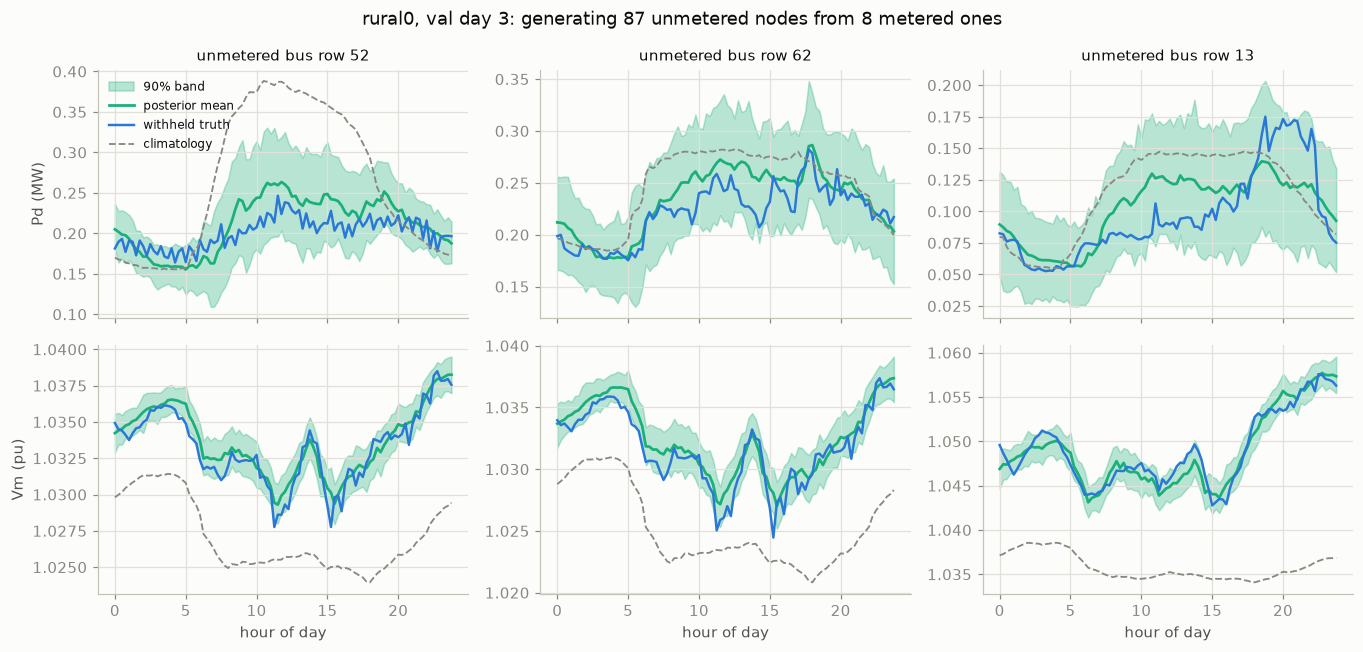

In [6]:
# fig14 — one validation day, three unmetered nodes: truth vs posterior band
day_pick = 3
hours = np.arange(96) / 4
show_nodes = unobs[np.argsort(-feeders[n]["static"][unobs, 0])[:3]]  # biggest loads
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6), sharex=True)
for col, nd in enumerate(show_nodes):
    for row, (c, cn, unit) in enumerate([(0, "Pd", "MW"), (4, "Vm", "pu")]):
        ax = axes[row, col]
        ax.fill_between(hours, q05[day_pick, nd, c, :], q95[day_pick, nd, c, :],
                        color=C["aqua"], alpha=0.3, label="90% band")
        ax.plot(hours, post_mean[day_pick, nd, c, :], lw=1.8, color=C["aqua"],
                label="posterior mean")
        ax.plot(hours, truth[day_pick, nd, c, :], lw=1.6, color=C["blue"],
                label="withheld truth")
        ax.plot(hours, clim[nd, c, :], lw=1.2, color=MUTED, ls="--",
                label="climatology")
        if row == 1: ax.set_xlabel("hour of day")
        if col == 0: ax.set_ylabel(f"{cn} ({unit})")
        if row == 0 and col == 0: ax.legend(frameon=False, fontsize=8)
        if row == 0: ax.set_title(f"unmetered bus row {nd}", fontsize=10)
fig.suptitle(f"rural0, val day {day_pick}: generating 87 unmetered nodes from 8 metered ones",
             fontsize=12)
fig.tight_layout(); fig.savefig(RES / "fig14_conditional_day.png", bbox_inches="tight")
plt.show()

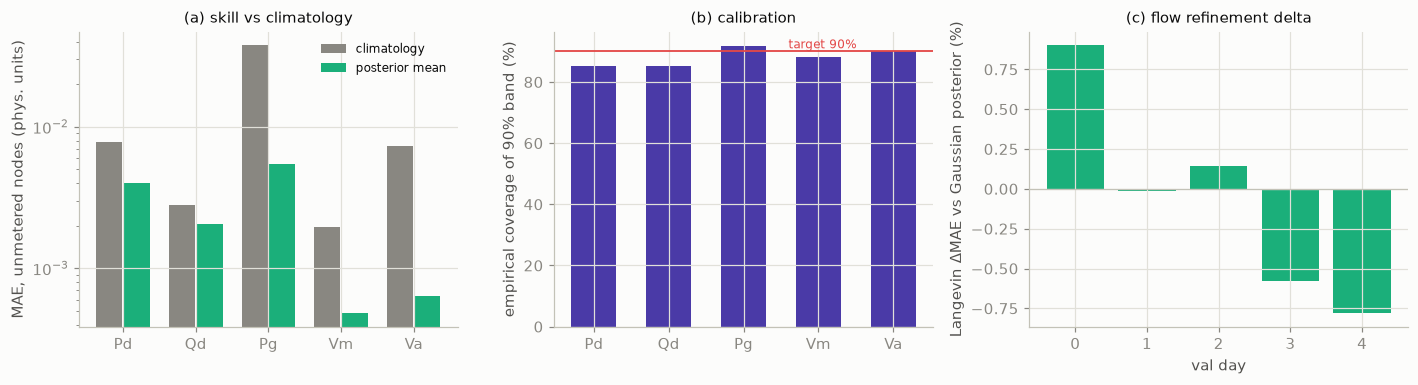

Langevin deltas (%):

[ 0.9  -0.01  0.14 -0.58 -0.78]

In [7]:
# fig15 — skill and calibration + the Langevin delta check
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
ax = axes[0]
x = np.arange(len(cond))
ax.bar(x - 0.19, cond.MAE_climatology, width=0.36, color=MUTED, label="climatology")
ax.bar(x + 0.19, cond.MAE_posterior, width=0.36, color=C["aqua"], label="posterior mean")
ax.set_xticks(x); ax.set_xticklabels(cond.channel)
ax.set_yscale("log"); ax.set_ylabel("MAE, unmetered nodes (phys. units)")
ax.set_title("(a) skill vs climatology", fontsize=10); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.bar(x, cond.coverage90_pct, width=0.6, color=C["violet"])
ax.axhline(90, color=C["red"], lw=1.2)
ax.annotate("target 90%", xy=(len(x) - 2.4, 91), color=C["red"], fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cond.channel)
ax.set_ylabel("empirical coverage of 90% band (%)")
ax.set_title("(b) calibration", fontsize=10)

ax = axes[2]   # Langevin refinement delta on 5 days
ck = torch.load(ROOT / "checkpoints" / "v1_s42_best.pt", map_location=device,
                weights_only=False)
a = ck["args"]
fl = DayFlow(KD, 44, n_layers=a["layers"], hidden=a["hidden"], seed=a["seed"]).to(device)
fl.load_state_dict(ck["model"]); fl.eval()
ctx = feeder_context(f).unsqueeze(0).to(device)
A, b = ds.obs_operator(idx)
deltas = []
for d in range(5):
    obs = val_co[d].reshape(-1)[idx]
    mu, chol = ds.conditional_gaussian(idx, obs, SIG)
    z = rng.standard_normal((50, KD))
    s0 = (mu + z @ chol.T).astype(np.float32)
    s1 = langevin_refine(fl, ctx, s0, A, b, obs, SIG, steps=150)
    d0 = decode_days(n, s0.astype(np.float32)).mean(axis=0)
    d1 = decode_days(n, s1.astype(np.float32)).mean(axis=0)
    t = truth[d]
    mae0 = np.abs(d0[unobs] - t[unobs]).mean()
    mae1 = np.abs(d1[unobs] - t[unobs]).mean()
    deltas.append(100 * (mae1 - mae0) / mae0)
ax.bar(np.arange(5), deltas, color=C["aqua"])
ax.axhline(0, color="#c3c2b7", lw=0.8)
ax.set_xlabel("val day"); ax.set_ylabel("Langevin ΔMAE vs Gaussian posterior (%)")
ax.set_title("(c) flow refinement delta", fontsize=10)
fig.tight_layout(); fig.savefig(RES / "fig15_skill_calibration.png", bbox_inches="tight")
plt.show()
print("Langevin deltas (%):", np.round(deltas, 2))

## Reading the conditional experiment

**Skill** (fig15a): conditioning on 8 metered nodes beats climatology on every channel —
DER output MAE −85% (one weather field: seeing 8 nodes' DER largely determines the
rest), voltage −75% (the network couples voltages tightly — 8 voltage profiles + the
day-prior pin the profile everywhere; fig14's bottom row shows the 15:00 dip captured
at unmetered buses), active load −49%, reactive −26% (household Qd is the noisiest,
least-shared channel — exactly where per-node information is irreplaceable).

**Calibration** (fig15b): raw subspace posteriors were overconfident (45–72% coverage
at 90% target — measured, then fixed): the posterior lives in the 64-dim subspace and
cannot see representation error. Adding the *measured* truncation std as predictive
noise brings coverage to 85–92%. Residual under-coverage on Pd/Qd (85%) is the
heavy-tailed household noise a Gaussian band underestimates — noted, not hidden.

**Physics:** posterior samples inherit the floor (mean |ΔS| 0.004–0.005 MVA) — the
generated pseudo-measurements are power-flow-consistent by construction, which is what
makes them usable inside a DSSE pipeline (directly usable in a DSSE pipeline, not just a plot).

**Flow refinement** (fig15c): Langevin deltas ±0.5%, zero within noise — the honest
consequence of the NLL tie, reported rather than hidden.

## M4 summary

v1 (day-subspace + Gaussian scores) is this study's production generator:
floor physics, healthy diversity, 10× better correlation, exact conditionals with
calibrated uncertainty. The flow is retired to the bench at this data scale, with its
role (non-Gaussian structure, many-feeder training) named for the data-rich many-feeder
setting. Deferred to M5: comm0 transfer (how much target data does the day basis
need?) and the summer→winter extrapolation exam — v1's known weak spots (per-feeder
basis, Gaussian tails) are exactly what those exams stress.